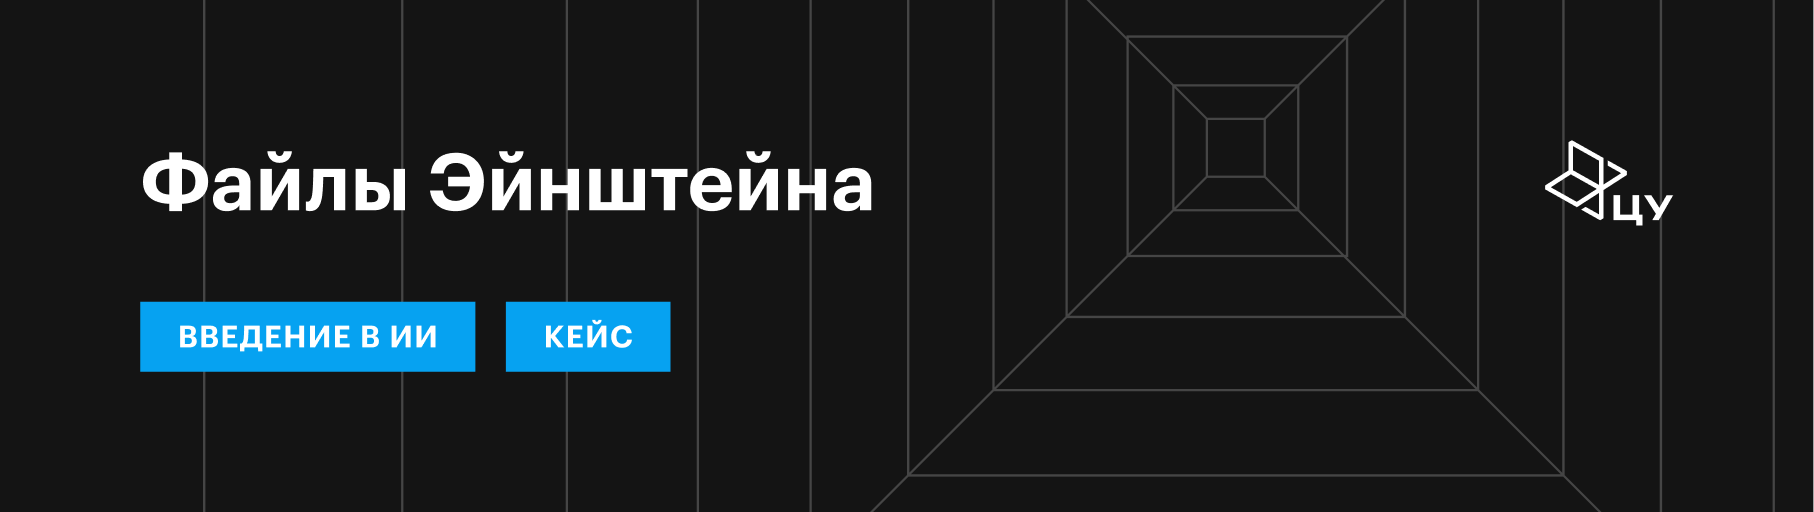

# Легенда

Ты работаешь в компании Х, которая занимается исследованием и сортировкой документов.
Недавно к тебе в руки попал ранее скрытый от глаз общественности материал *«Файлы Эйнштейна»*, содержащий тексты писем, написанных от руки великим учёным.

Один стажёр уже отсканировал файлы и начал вручную их расшифровывать. Однако старый офисный сканер оставил ошибки и артефакты на текстах, а вкупе с неразборчивым почерком Альберта Эйнштейна эта задача оказалась невыполнимой.

Поэтому твой начальник обратился к тебе с просьбой: «Сделайте так, чтобы компьютер сам всё прочитал. И чтобы потом можно было найти слово «бомба» или «антивселенная»: мало ли что там у этого Эйнштейна было на уме».

**Задача:** создать нейросетевую модель OCR (оптическое распознавание символов), которая сможет распознавать рукописный текст Эйнштейна с максимальной точностью.

# Требования к решению

Поскольку это учебный проект, вводятся следующие технические ограничения.

* **Ограничение по размеру модели:** решение должно корректно работать в Google Colab. Использовать несколько Google-аккаунтов для увеличения квоты на Т4 для экспериментов с архитектурой не запрещено.

* **Воспроизводимость:** весь код должен выполняться последовательно с первого раза. Обязательно фиксируй random_seed, а также сохраняй веса моделей и логируй эксперимент.

**Необходимые этапы решения**

1. *Обработка данных*. Внимательно изучи данные в датасете `einstein_files`. Предложи способ выделения символов из текста. Подумай, можно ли применять модель к сырым данным или нужно провести некоторые манипуляции.


2. *Выбор модели*. Напиши свою модель классификации рукописных букв английского алфавита или выбери предобученную.


3. *Решение задачи распознавания символов*. Обучение выбранной модели на датасете. Опиши, как осуществлялись подбор гиперпараметров, выбор метрики и валидация.

4. *Применение модели*. Финальный этап решения: объедини две основные составляющие в одну (выделение символов из изображения, их обработка моделью распознавания символов, составление полного текста). Результаты OCR будут проверяться по метрикам accuracy.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Система оценивания

Решение оценивается по трём параметрам.
* **Работа с данными [4 балла].** Оценка ставится в соответствии с тем, насколько подробно была произведена работа с данными. Визуализации, предобработка и очистка/обогащение датасета будут плюсом.

* **Решение задачи [4 балла].** Оценка ставится не за итоговые метрики (для простых моделей их значение может быть небольшим), а за то, насколько качественно были проделаны эксперименты в рамках выбранной модели. То есть если в решении используется примитивная модель, получающая низкие метрики, но она обучена с разными гиперпараметрами и приёмами так, что из её качества выжимается максимум, то это решение будет оценено в полный балл.

* **Оформление [2 балла].** Хочется, чтобы написанный код читался как хорошая книга. Для этого мы добавляем баллы за оформление, если в коде появляются визуализации, комментарии к коду и сопроводительный текст.

# Данные

Ниже написан код для скачивания датасета `einstien_files`, который содержит 46 изображений отсканированных документов с рукописным текстом на английском языке.

In [ ]:
!gdown 1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ
!unzip -q /content/einstein_files.zip
!rm /content/einstein_files.zip

# Твой код

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)

DATA_DIR = "/content/einstein_files"

# 1. Обработка картинок

## Сравнение медианного фильтра и морфологии с разными окнами (так как здесь salt-pepper шум)

In [ ]:
def binarize(image, apply_blur=False):
  if apply_blur:
    image = cv2.GaussianBlur(image, (3, 3), sigmaX=1)
  optimal_threshold, thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
  return thresh

In [ ]:
def compare_denoising_methods(image_path):
  img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

  median_3 = binarize(cv2.medianBlur(img, ksize=3))
  median_5 = binarize(cv2.medianBlur(img, ksize=5))

  kernel_1x2 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
  morph_2 = binarize(cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_1x2))

  # kernel_2x2 = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
  # morph_3 = binarize(cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_2x2), True)

  kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
  kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1))
  img_v = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_v)
  img_h = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_h)

  morph_img = binarize(cv2.bitwise_or(img_v, img_h))


  fig, axes = plt.subplots(1, 5, figsize=(20, 6))
  titles = ['Оригинал', 'Медиана (3x3)', 'Медиана (5x5)', 'Морфология (1x2)', 'Морфология (1x2), затем (2x1)']
  images = [img, median_3, median_5, morph_2, morph_img]

  for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

  plt.tight_layout()
  plt.show()

### Проверка на 1 картинке

In [ ]:
compare_denoising_methods(DATA_DIR+'/file_0.png')

### Сначала подумал, что самый лучший результат получился с медианным фильтром 3x3, но он портил некоторые тонкие линии, потом я решил выбрать морфологию 1x2, она оставляет немного шума, зато почти не меняет буквы. В итоге я заметил, что такой вариант сильно затирает тонкие горизонтальные линии, и выбрал независимое применение к осям, это решает такую проблему.

# Сегментация

### Функция для сегментации по площади

In [ ]:
def segment_characters(binary_image, min_area=5, max_area=1000):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid_bounding_boxes = []

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h

        if min_area < area < max_area:
            valid_bounding_boxes.append((x, y, w, h))

    return valid_bounding_boxes

In [ ]:
def visualize_bounding_boxes(image_path, boxes):
    img = cv2.imread(image_path)

    for (x, y, w, h) in boxes:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 1)

    plt.figure(figsize=(10, 12))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Найдено символов: {len(boxes)}")
    plt.axis('off')
    plt.show()

In [ ]:
def my_best_morph(img):
    kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1))
    img_v = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_v)
    img_h = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_h)
    morph_img = cv2.bitwise_or(img_v, img_h)

    return morph_img

In [ ]:
f = DATA_DIR+'/file_0.png'

img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
morph_img = my_best_morph(img)
img_bin = binarize(morph_img, True)

boxes = segment_characters(img_bin, min_area=10)
visualize_bounding_boxes(f, boxes)

Порог площади либо разделяет разные части букв, либо что-то не видит, поэтому я решил юзать маленький порог и потом объединять боксы

In [ ]:
def calculate_box_distances(b1, b2):
  x1, y1, w1, h1 = b1
  x2, y2, w2, h2 = b2

  h_dist = max(0, max(x1, x2) - min(x1 + w1, x2 + w2))
  v_dist = max(0, max(y1, y2) - min(y1 + h1, y2 + h2))

  return h_dist, v_dist

def merge_boxes(b1, b2):
  x1, y1, w1, h1 = b1
  x2, y2, w2, h2 = b2

  x = min(x1, x2)
  y = min(y1, y2)
  w = max(x1 + w1, x2 + w2) - x
  h = max(y1 + h1, y2 + h2) - y

  return (x, y, w, h)

def apply_box_merging(boxes, h_thresh_factor=0.3, v_thresh_factor=0.5):
  all_w = [b[2] for b in boxes]
  all_h = [b[3] for b in boxes]
  median_w = np.median(all_w)
  median_h = np.median(all_h)

  h_pixel_thresh = median_w * h_thresh_factor
  v_pixel_thresh = median_h * v_thresh_factor

  merged_any = True

  while merged_any:
    merged_any = False
    new_boxes = []
    skip_indices = set()

    for i in range(len(boxes)):
      if i in skip_indices:
        continue

      current_box = boxes[i]
      can_merge = False

      for j in range(i + 1, len(boxes)):
        if j in skip_indices:
          continue

        h_dist, v_dist = calculate_box_distances(current_box, boxes[j])

        if h_dist < h_pixel_thresh and v_dist < v_pixel_thresh:
          current_box = merge_boxes(current_box, boxes[j])
          skip_indices.add(j)
          merged_any = True
          can_merge = True

      new_boxes.append(current_box)

    boxes = new_boxes

  return boxes

In [ ]:
boxes_merged = apply_box_merging(boxes, h_thresh_factor=0.1, v_thresh_factor=0.2)
visualize_bounding_boxes(f, boxes_merged)

### С объединением тоже возникли проблемы, вертикальный множитель либо не соединяет i с точкой, либо соединяет соседние буквы. Поэтому я решил разделить тексрт на строки. Это помогло, но частично. В 10 стоке есть i, у которой точка очень далеко по горизонтали. Единственный способ это решить, что я придумал, это отказаться почти от всего что я сделал и разделить текст еще и на столбцы по буквам

#### Разделение текста на строки

In [ ]:
def segment_lines_midpoint(binary_image, empty_space_threshold=5, min_line_height=15):
    row_sums = np.sum(binary_image == 255, axis=1)

    bands = []
    in_band = False
    start_y = 0

    for y, row_sum in enumerate(row_sums):
        if row_sum > empty_space_threshold and not in_band:
            in_band = True
            start_y = y
        elif row_sum <= empty_space_threshold and in_band:
            in_band = False
            bands.append((start_y, y))

    if in_band:
        bands.append((start_y, len(row_sums)))

    valid_bands = [b for b in bands if (b[1] - b[0]) >= min_line_height]

    if not valid_bands:
        return []

    lines = []
    current_start = 0

    for i in range(len(valid_bands) - 1):
        gap_start = valid_bands[i][1]
        gap_end = valid_bands[i+1][0]

        midpoint = (gap_start + gap_end) // 2
        lines.append((current_start, midpoint))
        current_start = midpoint

    lines.append((current_start, binary_image.shape[0]))

    return lines

#### Функция для графика сетки

In [ ]:
def visualize_line_segmentation(image_path: str, lines_y_coords: list, step: int = 28):
    img = cv2.imread(image_path)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width = img_rgb.shape[:2]

    for (y_start, y_end) in lines_y_coords:
        cv2.line(img_rgb, (0, y_start), (img_width, y_start), (0, 255, 0), 1)
        cv2.line(img_rgb, (0, y_end), (img_width, y_end), (0, 255, 0), 1)

    for x in range(10, img_width, step):
        cv2.line(img_rgb, (x, 0), (x, img_height), (255, 0, 0), 1)

    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.title(f"Сегментация строк (Найдено: {len(lines_y_coords)}) | Шаг: {step}px", fontsize=14)
    plt.axis('off')
    plt.show()

In [ ]:
line_coords = segment_lines_midpoint(img_bin, empty_space_threshold=5)
visualize_line_segmentation(f, line_coords)

#### Получаем боксы по строкам и фикс. столбцам. По y боксы обрезаются по 1 и последнему белому пикселю, потом добавляются паддинги до 28 пикселей, чтобы буквы были в центре боксов

#### Я вспомнил про пробелы, поэтому сделал отдельную переменную где все хранится

In [ ]:
def extract_grid_boxes(clean_bin_img, lines_y_coords, margin_x=10, char_size=28, noise_threshold=20):
  img_height, img_width = clean_bin_img.shape
  columns = (img_width - margin_x * 2) // char_size

  valid_boxes = []
  ready_tokens = []

  for (y_start, y_end) in lines_y_coords:
    for col in range(columns):
      x_start = margin_x + col * char_size
      x_end = x_start + char_size

      cell_crop = clean_bin_img[y_start:y_end, x_start:x_end]

      if np.sum(cell_crop > 0) > noise_threshold:
        y_indices = np.where(cell_crop > 0)[0]

        if len(y_indices) > 0:
          local_y_min = y_indices[0]
          local_y_max = y_indices[-1]

          ink_height = (local_y_max - local_y_min) + 1
          ink_crop = cell_crop[local_y_min:local_y_max+1, :]

          final_28x28 = np.zeros((char_size, char_size), dtype=np.uint8)
          top_padding = (char_size - ink_height) // 2

          if ink_height <= char_size:
            ink_crop_255 = np.where(ink_crop > 0, 255, 0).astype(np.uint8)
            final_28x28[top_padding:top_padding+ink_height, :] = ink_crop_255
          else:
            final_28x28 = np.where(ink_crop[:char_size, :] > 0, 255, 0).astype(np.uint8)

          ready_tokens.append(final_28x28)

          global_y_start = (y_start + local_y_min) - top_padding
          valid_boxes.append((x_start, global_y_start, char_size, char_size))
      else:
        ready_tokens.append(None)

  return valid_boxes, ready_tokens

### Проверка

In [ ]:
f = DATA_DIR + '/file_0.png'

img= cv2.imread(f, cv2.IMREAD_GRAYSCALE)
morph_img = my_best_morph(img)
img_bin = binarize(morph_img, apply_blur=False)

lines = segment_lines_midpoint(img_bin, empty_space_threshold=5, min_line_height=15)
boxes, _ = extract_grid_boxes(img_bin, lines)
visualize_bounding_boxes(f, boxes)

In [ ]:
cv2.imwrite('img.png', img_bin)

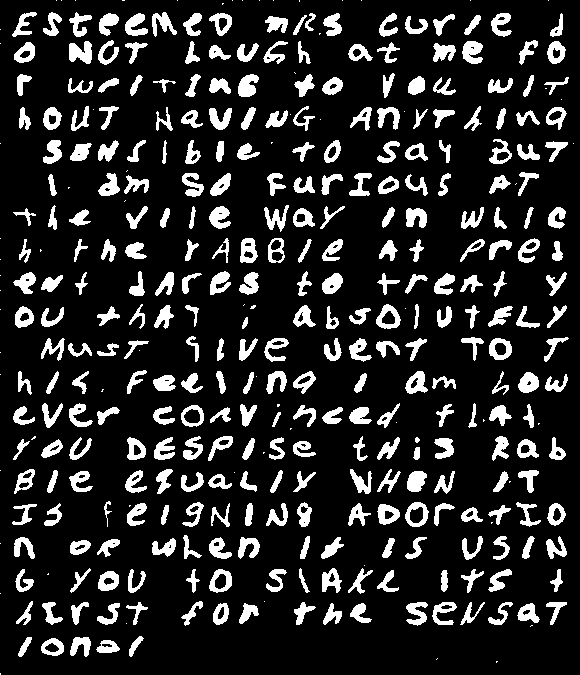

### Почти идеально, но остался довольно крупный шум, который все портит

#### Финальная очистка с cv2.connectedComponentsWithStats

In [ ]:
def remove_small_components(binary_image, min_area=10):
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_image)

  clean_image = np.zeros_like(binary_image)

  for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]

    if area >= min_area:
      clean_image[labels == i] = 255

  return clean_image

#### Еще одна проверка

In [ ]:
f = DATA_DIR + '/file_0.png'

img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
morph_img = my_best_morph(img)

img_bin = binarize(morph_img)
clean_bin = remove_small_components(img_bin, min_area=5)

In [ ]:
cv2.imwrite('final_clean_img.png', clean_bin)

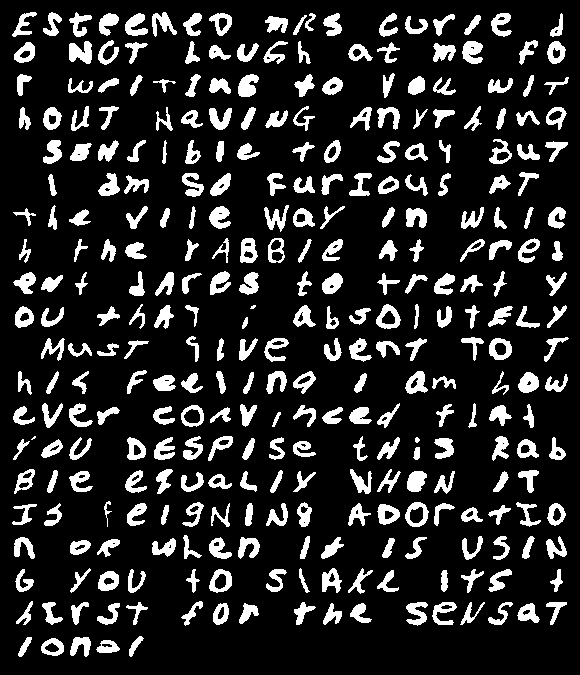

In [ ]:
lines = segment_lines_midpoint(clean_bin, empty_space_threshold=5, min_line_height=15)

boxes, _ = extract_grid_boxes(clean_bin, lines)

visualize_bounding_boxes(f, boxes)

## Ура, победа

# Загрузка датасета EMNIST

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    lambda img: transforms.functional.rotate(img, -90),
    lambda img: transforms.functional.hflip(img),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# split='letters', цифр я не нашел в файлах эйнштейна
train_dataset = datasets.EMNIST(root='./data', split='letters',
                                train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='letters',
                               train=False, download=True, transform=transform)

# Приводим таргеты от 1-26 к 0-25 для nn.CrossEntropyLoss
train_dataset.targets = train_dataset.targets - 1
test_dataset.targets = test_dataset.targets - 1

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# CNN

In [ ]:
class EMNISTClassifier(nn.Module):
  def __init__(self, num_classes=26):
    super().__init__()

    self.features = nn.Sequential(
      nn.Conv2d(1, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.Conv2d(32, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.Dropout2d(p=0.25),

      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.Conv2d(64, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.Dropout2d(p=0.25)
      )

    self.classifier = nn.Sequential(
      nn.Linear(64 * 7 * 7, 512),
      nn.BatchNorm1d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(p=0.5),
      nn.Linear(512, num_classes)
      )

  def forward(self, x):
    x = self.features(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)

    return x

In [ ]:
from tqdm import tqdm
from collections import defaultdict

def train_step(batch, model, loss, optimizer, device):
    model.zero_grad()
    X, y = batch
    X, y = X.to(device), y.to(device)

    logits = model(X)
    l = loss(logits, y)

    l.backward()
    optimizer.step()

    return logits.argmax(dim=-1).detach().cpu().numpy(), y.detach().cpu().numpy(), l.item()

def train(model, loss, optimizer, device, train_dataloader):
    model.train()
    train_loss = 0
    preds = []
    labels = []

    for batch in tqdm(train_dataloader, desc="Train", leave=False):
        preds_step, labels_step, loss_step = train_step(batch, model, loss, optimizer, device)
        train_loss += loss_step / len(train_dataloader)
        preds.append(preds_step)
        labels.append(labels_step)

    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    train_acc = np.mean(preds == labels)

    return train_acc, train_loss

def valid_step(batch, model, loss, device):
    X, y = batch
    X, y = X.to(device), y.to(device)

    with torch.no_grad():
        logits = model(X)
        l = loss(logits, y)

    return logits.argmax(dim=-1).detach().cpu().numpy(), y.detach().cpu().numpy(), l.item()

def validate(model, loss, device, val_dataloader):
    model.eval()
    val_loss = 0
    preds = []
    labels = []

    for batch in tqdm(val_dataloader, desc="Valid", leave=False):
        preds_step, labels_step, loss_step = valid_step(batch, model, loss, device)
        val_loss += loss_step / len(val_dataloader)
        preds.append(preds_step)
        labels.append(labels_step)

    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    val_acc = np.mean(preds == labels)

    return val_acc, val_loss

def train_and_validate(model, loss, optimizer, train_dataloader, val_dataloader, num_epochs=15, device='cuda', naming=''):
    model.to(device)
    history = defaultdict(lambda: defaultdict(list))
    best_acc = 0.0

    for e in range(num_epochs):
        train_acc, train_loss = train(model, loss, optimizer, device, train_dataloader)
        val_acc, val_loss = validate(model, loss, device, val_dataloader)

        history['loss']['train'].append(train_loss)
        history['acc']['train'].append(train_acc)
        history['loss']['val'].append(val_loss)
        history['acc']['val'].append(val_acc)

        print(f'Эпоха: {e + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}%')

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_model{naming}.pth')

    return model, history

# Подбор гиперпараметров

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

learning_rates = [1e-3, 5e-4]
weight_decays = [1e-4, 1e-5]

best_acc = 0.0
best_params = {}

for lr in learning_rates:
  for wd in weight_decays:
    print(f"\n LR={lr}, WD={wd}")
    model = EMNISTClassifier(num_classes=26)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = torch.nn.CrossEntropyLoss()

    _, history = train_and_validate(
        model=model,
        loss=criterion,
        optimizer=optimizer,
        train_dataloader=train_loader,
        val_dataloader=test_loader,
        num_epochs=3,
        device=device,
        naming=f'_lr{lr}_wd{wd}'
        )

    val_acc = history['acc']['val'][-1]
    if val_acc > best_acc:
      best_acc = val_acc
      best_params = {'lr': lr, 'wd': wd}

print(f"\n best_params: {best_params} | acc: {best_acc*100:.2f}%")

In [ ]:
model = EMNISTClassifier(num_classes=26)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=best_params['lr'], weight_decay=best_params['wd'])

model, history = train_and_validate(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    train_dataloader=train_loader,
    val_dataloader=test_loader,
    num_epochs=15,
    device=device,
    naming='_emnist'
)

# Итог

В этом разделе мы подведём итоги обработки данных и обучения модели OCR. Для этого мы используем две метрики — **Character Error Rate** (CER) и **Word Error Rate** (WER).

1. CER вычисляется как расстояние Левенштейна (то есть количество замен символов, необходимое для перевода одной строки в другую) между исходным текстом и распознанным, делённое на количество символов.

2. WER вычисляется как процент совпадающих слов.

In [ ]:
!pip install Levenshtein

In [ ]:
from Levenshtein import distance

def character_error_rate(pred_text, real_text):
    """Расстояние Левенштейна"""
    return distance(pred_text, real_text) / len(real_text)

In [ ]:
def word_error_rate(pred_text, real_text):
    """Процент слов, распознанных с ошибкой"""
    pred_words = pred_text.split()
    true_words = real_text.split()

    if len(true_words) == 0:
        return 0 if len(pred_words) == 0 else 1.0

    errors = sum(1 for p, t in zip(pred_words, true_words) if p != t)
    errors += abs(len(pred_words) - len(true_words))

    return errors / len(true_words)

Напиши функцию для обработки файлов Эйнштейна. Она должна принимать на вход датасет `epstein_files` (чтение данных и их обработку ты выбираешь и реализовываешь самостоятельно) и твою модель OCR `model`. На выходе — распознанный текст.

In [ ]:
import re

def predict_text_with_formatting(model, tokens, device):
    model.eval()
    # Индексы 0-25 соответствуют a-z
    label_to_char = {i: chr(i + 97) for i in range(26)}
    predicted_text = ""

    with torch.no_grad():
      for item in tokens:
        if item is None:
          predicted_text += " "
        elif isinstance(item, np.ndarray):
          tensor = torch.from_numpy(item).float() / 255.0
          tensor = (tensor - 0.5) / 0.5
          tensor = tensor.unsqueeze(0).unsqueeze(0).to(device)

          outputs = model(tensor)
          _, predicted_idx = torch.max(outputs, 1)
          idx = predicted_idx.item()

          predicted_text += label_to_char[idx]

    cleaned_text = re.sub(r' +', ' ', predicted_text).strip()
    return cleaned_text

In [ ]:
def process(einstein_files, model):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)

  all_texts = []

  for file_path in tqdm(sorted(einstein_files), desc="Распознавание"):
    img_gray = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    morph_img = my_best_morph(img_gray)

    img_bin = binarize(morph_img)

    clean_bin = remove_small_components(img_bin, min_area=5)

    lines = segment_lines_midpoint(clean_bin, empty_space_threshold=5, min_line_height=15)

    _, tokens = extract_grid_boxes(
        clean_bin,
        lines,
        margin_x=10,
        char_size=28,
        noise_threshold=5
        )

    file_text = predict_text_with_formatting(model, tokens, device)
    if file_text:
      all_texts.append(file_text)

  final_full_text = " ".join(all_texts)
  return final_full_text

In [ ]:
einstein_files = ['/content/einstein_files/file_'+str(x)+'.png' for x in range(46)]

In [ ]:
pred_text = process(einstein_files, model)

In [ ]:
pred_text

In [ ]:
with open('shitty_text.txt', 'w', encoding='utf-8') as file:
    file.write(pred_text)

Прочитай текстовый файл с реальным текстом файлов Эйнштейна и оцени качество модели с помощью метрик выше.

**ВНИМАНИЕ.** Данный файл в целях академической честности может быть прочтён и использован только в части кода снизу.

In [ ]:
!gdown 1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC

In [ ]:
with open('top_secret.txt', 'r', encoding='utf-8') as file:
    real_text = file.read().lower()

In [ ]:
wer = word_error_rate(pred_text, real_text)
cer = character_error_rate(pred_text, real_text)
print(f"WER = {wer}")
print(f"CER = {cer}")

**Выводы:**
Очень много времени потратил на сегментацию, результатом этой части я доволен. В итоге метрики получились очень плохими, текст читается с трудом. Скорее всего из-за того, что обработка хороша для сегментации, но она сильно изменяет буквы. Если бы я делал это заново, я сделал бы добавление шума в обучающий датасет и обрабатывал бы исходные, нетронутые файлы Эйнштейна. Если бы получились метрики получше, я бы возможно сделал еще пост-обработку текста, чтобы исправить ошибки на уровне опечаток, но с моими результатами это бессмысленно.